# Data analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.plotting_functions import *

Testing
Plotting colors safely loaded


In [2]:
save_figs = False

In [3]:
wanted_parameters = ["BG_NOISE", 
                     "RA_NOISE", 
                     "LEARNING_RATE_HL",
                     "LEARNING_RATE_RL", 
                     "N_DISTRACTORS",
                     "ANNEALING",
                     "TARGET_WIDTH",
                     "REWARD_WINDOW",
                     "JUMP_FACTOR",
                     "JUMP_MID"] 
                     # expand here

In [4]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE.parent / "Robustness" / "results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

ANNEALING
BG_NOISE
JUMP_FACTOR
JUMP_MID
LEARNING_RATE_HL
LEARNING_RATE_RL
N_DISTRACTORS
N_DISTRACTORS_old
RA_NOISE
REWARD_WINDOW
TARGET_WIDTH
[WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_ANNEALING'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_BG_NOISE'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_JUMP_FACTOR'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_JUMP_MID'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_LEARNING_RATE_HL'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_LEARNING_RATE_RL'), WindowsPath('C:/Users/rsankar/Des

In [5]:
terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)
    if param == "N_DISTRACTORS":
        print(f"Processing {folder.name} with special handling for N_DISTRACTORS")
        nos_peaks_path = folder / "nos_peaks.npy"
        if nos_peaks_path.exists():
            nos_peaks = np.load(nos_peaks_path)
            print(f"Loaded nos_peaks for {folder.name}")
        else:
            print(f"⚠️ Missing nos_peaks.npy for {folder.name}")

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


Processing params_N_DISTRACTORS with special handling for N_DISTRACTORS
Loaded nos_peaks for params_N_DISTRACTORS


In [8]:
terminal_performance['BG_NOISE'].shape, meta['BG_NOISE'].keys()

((100, 7), dict_keys(['parameter', 'section', 'seeds', 'shape', 'values']))

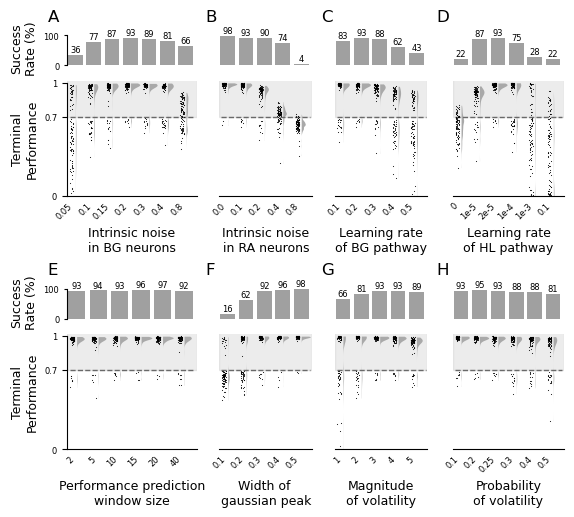

In [12]:
plt.rcParams.update({'font.family': 'sans-serif'})

# bar rows : violin rows = 3 : 10 — encoded directly in the layout string
# A-H = violin panels, 1-4 / 5-8 = matching success-rate bars
layout = """
1234
1234
1234
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
5678
5678
5678
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
"""

params_mosaic = [
    ("BG_NOISE",         "Intrinsic noise\nin BG neurons",        '1', 'A'),
    ("RA_NOISE",         "Intrinsic noise\nin RA neurons",         '2', 'B'),
    ("LEARNING_RATE_RL", "Learning rate\nof BG pathway",           '3', 'C'),
    ("LEARNING_RATE_HL", "Learning rate\nof HL pathway",           '4', 'D'),
    ("REWARD_WINDOW",    "Performance prediction\nwindow size",            '5', 'E'),
    ("TARGET_WIDTH",     "Width of \ngaussian peak",        '6', 'F'),
    ("JUMP_FACTOR",      "Magnitude\nof volatility",   '7', 'G'),
    ("JUMP_MID",         "Probability\nof volatility", '8', 'H'),
]

def fmt_sci(v):
    if v == 0:
        return '0'
    exp   = int(np.floor(np.log10(abs(v))))
    coeff = round(v / 10 ** exp)
    return f"{coeff}e{exp}"

def fmt_int(v):
    return str(int(v))

def fmt_decimal(v):
    return f"{v:.10f}".rstrip('0').rstrip('.')

LABEL_FORMATTERS = {
    "LEARNING_RATE_HL": fmt_sci,
    "REWARD_WINDOW":    fmt_int,
    "JUMP_FACTOR":      fmt_int,
}

THRESHOLD          = 0.7
color_violin       = 'darkgray'
color_bar          = 'grey'
color_strip        = 'black'
FONTSIZE_LABEL     = 9
FONTSIZE_BAR_LABEL = 9
FONTSIZE_TICK      = 6

fig_width  = 405 / 72
fig_height = fig_width * 0.9

# Column widths proportional to number of x-values so each bar has equal visual width
row1 = [p for p, _, bk, _ in params_mosaic if bk in '1234']
row2 = [p for p, _, bk, _ in params_mosaic if bk in '5678']
width_ratios = [
    max(len(meta[p1]["values"]), len(meta[p2]["values"]))
    for p1, p2 in zip(row1, row2)
]

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(fig_width, fig_height),
    layout="constrained",
    gridspec_kw={"width_ratios": width_ratios},
)

for col_idx, (param, xlabel, bar_key, vln_key) in enumerate(params_mosaic):
    ax_bar = axs[bar_key]
    ax_vln = axs[vln_key]
    col    = col_idx % 4

    returns    = np.asarray(terminal_performance[param])
    param_vals = meta[param]["values"]
    n          = len(param_vals)

    above_threshold = np.array([np.mean(returns[:, i] > THRESHOLD) for i in range(n)])

    data, labels_list = [], []
    for i in range(n):
        data.extend(returns[:, i])
        labels_list.extend([param_vals[i]] * returns.shape[0])

    fmt = LABEL_FORMATTERS.get(param)
    xticklabels = [fmt(v) for v in param_vals] if fmt else list(param_vals)
    if param == "LEARNING_RATE_HL":
        xticklabels[0]  = fmt_decimal(param_vals[0])
        xticklabels[-1] = fmt_decimal(param_vals[-1])

    # --- Violin ---
    ax_vln.axhspan(THRESHOLD, 1.05, alpha=0.15, color='grey')
    sns.violinplot(x=labels_list, y=data, inner=None, color=color_violin,
                   linewidth=0, cut=0, bw_adjust=0.5, width=1, ax=ax_vln)
    for c in ax_vln.collections:
        if hasattr(c, "get_paths"):
            for path in c.get_paths():
                verts = path.vertices
                verts[:, 0] = np.maximum(verts[:, 0], np.median(verts[:, 0]))
    strip = sns.stripplot(x=labels_list, y=data, size=0.8, color=color_strip,
                          alpha=0.9, jitter=0.1, ax=ax_vln)
    for coll in strip.collections:
        offsets = coll.get_offsets()
        offsets[:, 0] -= 0.2
        coll.set_offsets(offsets)
    ax_vln.axhline(THRESHOLD, 0.02, 0.98, color='dimgray', linestyle='--', linewidth=1)
    ax_vln.set_ylim(0, 1.015)
    ax_vln.set_yticks([0, THRESHOLD, 1])
    ax_vln.set_xlim(-0.45, n - 0.4)
    ax_vln.set_xticks(np.arange(n) - 0.05)
    ax_vln.set_xticklabels(xticklabels, fontsize=FONTSIZE_TICK, rotation=45, ha='right')
    ax_vln.tick_params(axis='x', length=0)
    ax_vln.set_xlabel(xlabel, fontsize=FONTSIZE_LABEL)
    ax_vln.spines['top'].set_visible(False)
    ax_vln.spines['right'].set_visible(False)
    if col == 0:
        ax_vln.spines['left'].set_bounds(0, 1)
        ax_vln.set_yticklabels(['0', '0.7', '1'], fontsize=FONTSIZE_TICK)
        ax_vln.set_ylabel('Terminal\nPerformance', fontsize=FONTSIZE_LABEL)
    else:
        ax_vln.spines['left'].set_visible(False)
        ax_vln.tick_params(axis='y', left=False)
        ax_vln.set_yticklabels([])
        ax_vln.set_ylabel('')

    # --- Success-rate bar ---
    ax_bar.bar(range(n), above_threshold * 100, color=color_bar, alpha=0.75)
    for i, val in enumerate(above_threshold * 100):
        ax_bar.text(i, val + 3, f"{int(val)}",
                    ha='center', va='bottom', fontsize=6)
    ax_bar.set_ylim(0, 115)
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.45, n - 0.4)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_visible(False)
    if col == 0:
        ax_bar.tick_params(axis='y', length=2, labelsize=FONTSIZE_TICK)
        ax_bar.set_yticks([0, 100])
        ax_bar.set_yticklabels(['0', '100'], fontsize=FONTSIZE_TICK)
        ax_bar.set_ylabel('Success\nRate (%)', fontsize=FONTSIZE_BAR_LABEL)
        ax_bar.spines['left'].set_bounds(0, 100)
    else:
        ax_bar.spines['left'].set_visible(False)
        ax_bar.tick_params(axis='y', left=False)
        ax_bar.set_yticks([])
        ax_bar.set_ylabel('')

    # Panel label (A–H) — shifted left of subplot boundary
    ax_bar.text(-0.15, 1.2, vln_key, transform=ax_bar.transAxes,
                fontsize=12, va='bottom', ha='left')

fig.align_xlabels([axs[k] for k in 'ABCDEFGH'])
# plt.tight_layout()
save_figure('figure_8_robustness', format="pdf", save=False, dpi=600)
plt.show()


In [14]:
param_g = "JUMP_FACTOR"
returns_g = np.asarray(terminal_performance[param_g])
param_vals_g = meta[param_g]["values"]
n_g = len(param_vals_g)

above_threshold_g = np.array([np.mean(returns_g[:, i] > THRESHOLD) for i in range(n_g)])

print(f"Parameter: {param_g}")
print(f"Values: {param_vals_g}")
print(f"Returns shape: {returns_g.shape}")
print(f"\nPer-value statistics:")
for i, v in enumerate(param_vals_g):
    col_data = returns_g[:, i]
    print(f"  {v}: mean={col_data.mean():.4f}, std={col_data.std():.4f}, "
          f"min={col_data.min():.4f}, max={col_data.max():.4f}, "
          f"success_rate={above_threshold_g[i]*100:.1f}%")

print(f"\nFull returns array:\n{returns_g}")

Parameter: JUMP_FACTOR
Values: [1.0, 2.0, 3.0, 4.0, 5.0]
Returns shape: (100, 5)

Per-value statistics:
  1.0: mean=0.8291, std=0.2507, min=0.0000, max=0.9994, success_rate=66.0%
  2.0: mean=0.9167, std=0.1530, min=0.4527, max=0.9995, success_rate=81.0%
  3.0: mean=0.9614, std=0.0876, min=0.6110, max=0.9979, success_rate=93.0%
  4.0: mean=0.9545, std=0.0839, min=0.6082, max=0.9980, success_rate=93.0%
  5.0: mean=0.9180, std=0.1069, min=0.5539, max=0.9907, success_rate=89.0%

Full returns array:
[[9.75903574e-01 9.88634323e-01 9.89412436e-01 9.77734081e-01
  9.33942688e-01]
 [9.92450997e-01 9.91558957e-01 9.88627273e-01 9.80906412e-01
  9.66803870e-01]
 [9.64407529e-01 9.84581048e-01 9.91383385e-01 9.57087066e-01
  6.48267667e-01]
 [6.50304688e-01 9.89401714e-01 9.97910030e-01 9.37787407e-01
  9.56727582e-01]
 [9.89493173e-01 9.90934873e-01 9.91251434e-01 9.70757651e-01
  9.68983152e-01]
 [6.08224771e-01 6.08984087e-01 9.77196097e-01 9.37871457e-01
  9.48875385e-01]
 [9.83136374e-01 9.8

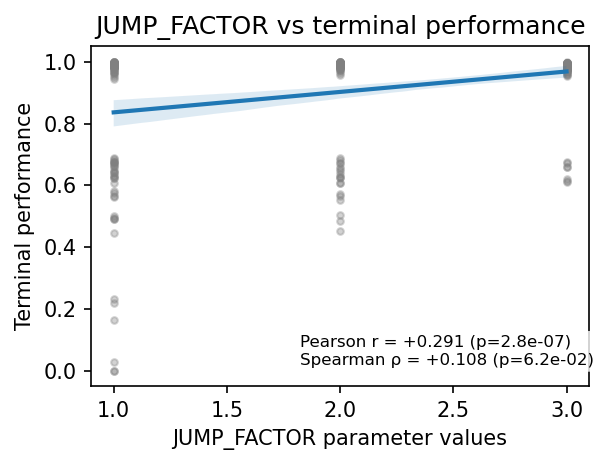

In [27]:
from scipy import stats

param = "JUMP_FACTOR"
vals_trimmed = np.asarray(meta[param]["values"][:-2], dtype=float)
ret_trimmed = np.asarray(terminal_performance[param][:, :-2], dtype=float)
# vals = np.asarray(meta[param]["values"], dtype=float)
# ret = np.asarray(terminal_performance[param], dtype=float)

x = np.tile(vals_trimmed, ret_trimmed.shape[0]) if ret_trimmed.ndim > 1 else vals_trimmed
y = ret_trimmed.reshape(-1) if ret_trimmed.ndim > 1 else ret_trimmed

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_rho, spearman_p = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(4.2, 3.2), dpi=150)

sns.regplot(
    x=x, y=y, ax=ax, ci=95,
    scatter_kws={"s": 10, "alpha": 0.35, "color": "gray"},
    line_kws={"color": "tab:blue", "lw": 2}
)

# if ret.ndim > 1:
#     ax.plot(vals, ret.mean(axis=0), marker="o", lw=1.5, color="tab:red", label="Mean per value")
    # ax.legend(frameon=False, fontsize=8, loc="lower left")

ax.set_xlabel("JUMP_FACTOR parameter values")
ax.set_ylabel("Terminal performance")
ax.set_title("JUMP_FACTOR vs terminal performance")

ax.text(
    0.42, 0.15,
    f"Pearson r = {pearson_r:+.3f} (p={pearson_p:.1e})\n"
    f"Spearman ρ = {spearman_rho:+.3f} (p={spearman_p:.1e})",
    transform=ax.transAxes, va="top", ha="left", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()

In [15]:
raise SystemExit("Old code")

SystemExit: Old code

In [ ]:
# plot_results_violin(
#     terminal_performance["N_DISTRACTORS"], 
#     meta["N_DISTRACTORS"]["values"],
#     big_xlabel="Number of Distractors"
# )

# if save_figs:
#     save_figure('9_robustness_N_DISTRACTORS', format="pdf", save=save_figs)

# plot_results_violin(
#     terminal_performance["ANNEALING"], 
#     meta["ANNEALING"]["values"],
#     big_xlabel="Annealing"
# )

# if save_figs:
#     save_figure('9_robustness_ANNEALING', format="pdf", save=save_figs)